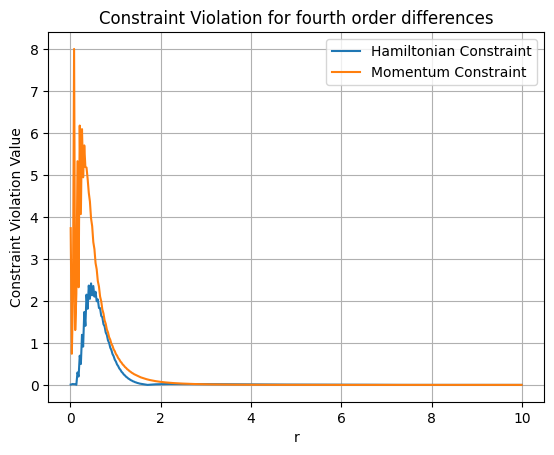

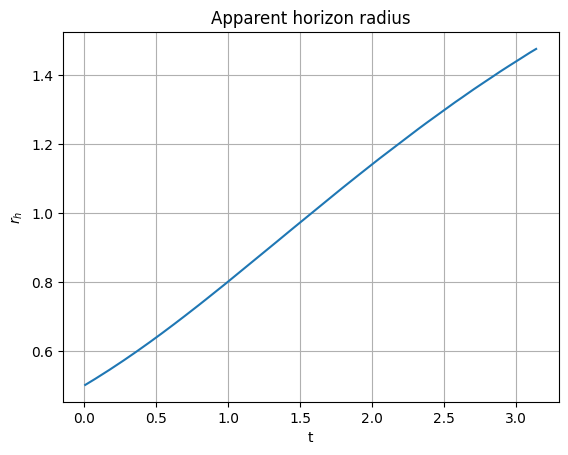

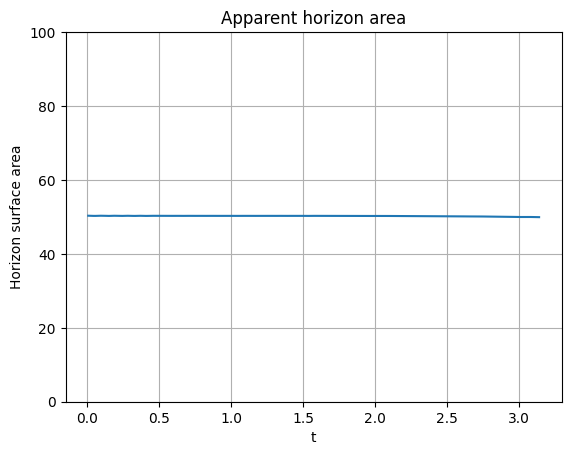

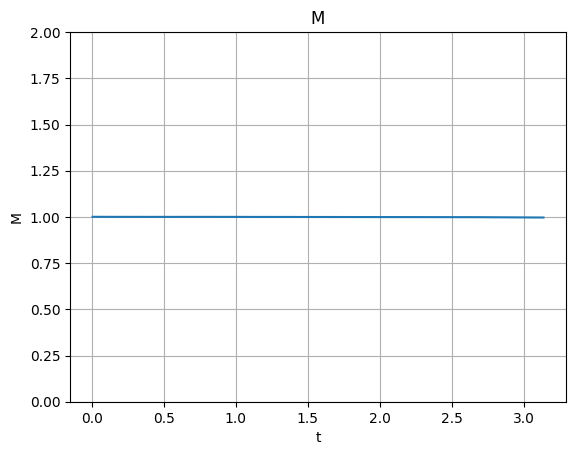

In [ ]:
#@title 1.4 Apparent Horizon

#importing libraries
import numpy as np
import matplotlib.pyplot as plt
import math

#parameters
N = 400
M = 1
dr = 0.025
dt = 0.25*dr
t_max = np.pi * M
time_step = int(t_max/dt)

#staggered grid
r_j = (0.5 + np.arange(N)) * dr

#given variables
A_b = np.ones(r_j.shape)
B_b = np.ones(r_j.shape)
DA_b = np.zeros(r_j.shape)
DB_b = np.zeros(r_j.shape)
alpha = np.ones(r_j.shape)
KA = np.zeros(r_j.shape)
KB = np.zeros(r_j.shape)

#regularisation
psi = 1.0 + M/(2.0 * r_j)
E = 4.0 * np.gradient(np.log(psi), dr)

#Boundary Conditions
def boundary_condition(f, parity='even'):
  n = len(f)

  g = np.zeros(n + 4)
  g[2:-2] = f
  if parity == 'even':
        g[1] = f[0]
        g[0] = f[1]
  else:
        g[1] = -f[0]
        g[0] = -f[1]

  g[-2] = g[-3]
  g[-1] = g[-3]
  return g

#finite difference
def fourth_order_finite_difference(f,parity):
  f4=boundary_condition(f,parity)
  df4=(-f4[4:] + 8*f4[3:-1] - 8*f4[1:-3] + f4[:-4]) / (12 * dr)
  return df4

#constraints
def hamiltonian_constraint(A_b, DA_b, DB_b, KA, KB):

  A  = A_b * psi**4
  DA = DA_b + E
  DB = DB_b + E

  dDB_dr = fourth_order_finite_difference(DB, 'odd')

  Ha = ((-dDB_dr - 0.5 * DB**2 + 0.5 * DA * DB + (DA - 2.0 * DB) / r_j) / A + KA**2 + 2.0 * KB**2)

  return Ha

def momentum_constraint(DA_b, DB_b, KA, KB):

  DA = DA_b + E
  DB = DB_b + E

  dKB_dr = fourth_order_finite_difference(KB, 'even')

  p = (dKB_dr+ (KB - KA) / r_j + 1.5 * DB * KB - 0.5 * DA * KA)

  return p


# Regularised ADM + 1+log slicing
def regularised_ADM(rhs):

  A_b, B_b, DA_b, DB_b, KA, KB, alpha = rhs

  A = A_b * psi**4
  B = B_b * psi**4
  DA = DA_b + E
  DB = DB_b + E
  alpha_safe = np.maximum(alpha, 1e-12)
  K  = KA + 2.0 * KB
  dalpha_dr = fourth_order_finite_difference(np.log(alpha_safe), dr)

  dAb_dt  = -2.0 * alpha * A_b * KA
  dBb_dt  = -2.0 * alpha * B_b * KB
  dDAb_dt = -2.0 * alpha * (KA * dalpha_dr + fourth_order_finite_difference(KA, 'even'))
  dDBb_dt = -2.0 * alpha * (KB * dalpha_dr + fourth_order_finite_difference(KB, 'even'))
  K = KA + 2.0 * KB

  dKa_dt = -alpha_safe/A*(fourth_order_finite_difference(dalpha_dr + DB, 'even') + dalpha_dr**2 + 0.5*DB**2 - 0.5*DA*DB - ((DA - 2.0*DB)/r_j)) + alpha_safe*KA*(K)

  dKb_dt = -alpha_safe/(2.0*A)*(fourth_order_finite_difference(DB, 'odd') + DB * dalpha_dr + DB**2 - 0.5*DA*DB - (DA - 2*dalpha_dr - 4.0*DB)/r_j - 2.0*(A_b - B_b)/(r_j**2*B_b)) + alpha_safe * KB*(K)

  dalpha_dt = -2.0 * alpha_safe * K
  return np.array([dAb_dt, dBb_dt, dDAb_dt, dDBb_dt, dKa_dt, dKb_dt, dalpha_dt])


# RK4 step
def rk4_step(rhs):

  k1 = regularised_ADM(rhs)
  k2 = regularised_ADM(rhs + 0.5 * dt * k1)
  k3 = regularised_ADM(rhs + 0.5 * dt * k2)
  k4 = regularised_ADM(rhs + dt * k3)

  return rhs + dt / 6.0 * (k1 + 2*k2 + 2*k3 + k4)

#Apparent horizon expansion
def expansion_H(A_b, B_b, DB_b, KB):

  A = A_b * psi**4
  B = B_b * psi**4
  DB = DB_b + E

  H = (1.0 / np.sqrt(A)) * ((2.0/r_j) + (fourth_order_finite_difference(B, 'even')/B)) - 2.0 * KB
  return H

#Apparent horizon finder
def apparent_horizon(H):
  for i in range(len(H)-1):
    if r_j[i] < 0.1:

         continue
    if H[i]*H[i+1] < 0:

        return np.interp(0, [H[i], H[i+1]], [r_j[i], r_j[i+1]])

  return None

#Evolution loop
rh_list = []
Sh_list = []
t_list  = []
M_list = []

rhs = np.stack([A_b, B_b, DA_b, DB_b, KA, KB, alpha]).astype(float)
t = 0.0


for n in range(time_step):

  rhs = rk4_step(rhs)
  A_b, B_b, DA_b, DB_b, KA, KB, alpha = rhs
  t += dt
  Hc = hamiltonian_constraint(A_b, DA_b, DB_b, KA, KB)
  Mc = momentum_constraint(DA_b, DB_b, KA, KB)

  H = expansion_H(A_b, B_b, DB_b, KB)
  rh = apparent_horizon(H)

  if rh is not None:

    psi_h = np.interp(rh,r_j,psi)
    Bbar_h = np.interp(rh,r_j,B_b)

    B_h = Bbar_h * psi_h**4

    Sh = 4.0 * np.pi * rh**2 * B_h
    M_h = np.sqrt(Sh/(16.0 * np.pi))

    rh_list.append(rh)
    M_list.append(M_h)
    Sh_list.append(Sh)
    t_list.append(t)

#Plotting
plt.figure()
plt.plot(r_j, np.abs(Hc), label = 'Hamiltonian Constraint')
plt.plot(r_j, np.abs(Mc), label = 'Momentum Constraint')
plt.legend()
plt.xlabel("r")
plt.ylabel(r"Constraint Violation Value")
plt.title("Constraint Violation for fourth order differences")
plt.grid()

plt.figure()
plt.plot(t_list, rh_list)
plt.xlabel("t")
plt.ylabel(r"$r_h$")
plt.title("Apparent horizon radius")
plt.grid()

plt.figure()
plt.plot(t_list, Sh_list)
plt.xlabel("t")
plt.ylabel("Horizon surface area")
plt.ylim(0, 100)
plt.title("Apparent horizon area")
plt.grid()

plt.figure()
plt.plot(t_list, M_list)
plt.ylim(0.00, 2.00)
plt.xlabel("t")
plt.ylabel("M")
plt.title("M")
plt.grid()

plt.show()